# 本章知识点总结：注意力机制（Attention Mechanism）

> 核心一句话：注意力机制就是用一个**查询（query）**去和一组**键（key）**做匹配，按匹配度对相应的**值（value）**做**加权平均**。本章从心理学引入这套抽象，再用 Nadaraya-Watson 核回归（非参 → 带参）作为最简单的实例落地。

---

## 1. 心理学动机：随意线索 vs 不随意线索

- **不随意线索（非自主性提示）**：环境中天然显眼、被动吸引注意的东西（如一个鲜艳的红杯子）。
- **随意线索（自主性提示）**：由主观意图主动发起的关注（如"我现在想读书"）。
- 对应到深度学习：**卷积 / 全连接 / 池化层只考虑了"不随意线索"**（被动处理所有输入）；而**注意力机制显式地引入了"随意线索"**，让模型能主动选择关注哪些输入。

---

## 2. 注意力的核心抽象：query / key / value

| 概念 | 含义 | 对应线索 |
|------|------|----------|
| **query（查询）** | 主动发起的查询意图 | 随意线索 |
| **key（键）** | 每个输入自带的"索引"标签 | 不随意线索 |
| **value（值）** | 每个输入实际携带的信息 | 感官输入 |

- 每个输入被组织成一个 **(key, value) 对**。
- 注意力池化层（attention pooling）用 query 去匹配所有 key，得到一组权重，再对 value 加权求和 → 输出。
- 这就实现了"带偏向性地选择某些输入"。

---

## 3. 非参注意力池化层：Nadaraya-Watson 核回归

给定数据 $(x_i, y_i),\; i = 1, \dots, n$。

**最简单的方案——平均池化**（完全不看 query，所有样本一视同仁）：

$$f(x) = \frac{1}{n} \sum_{i=1}^{n} y_i$$

- **字符定义**：$x$ 是查询点，$y_i$ 是第 $i$ 个训练样本的标签，$n$ 是样本数。
- **公式描述**：直接把所有标签求平均当预测，预测出一条水平直线，完全忽略了 $x$ 与样本的远近关系——效果很差。

**更好的方案——Nadaraya-Watson 核回归**（1964 年提出）：

$$f(x) = \sum_{i=1}^{n} \frac{K(x - x_i)}{\sum_{j=1}^{n} K(x - x_j)}\, y_i$$

- **字符定义**：
  - $x$：query（查询点，要预测的位置）
  - $x_i$：key（第 $i$ 个训练样本的输入）
  - $y_i$：value（第 $i$ 个训练样本的标签）
  - $K(\cdot)$：**核函数**，衡量两点的"接近程度"，越近值越大
- **公式描述**：分式部分就是**注意力权重**——它衡量"查询 $x$ 与每个 key $x_i$ 有多接近"，并通过分母归一化使所有权重之和为 1；然后用这些权重对 value $y_i$ 加权求和。**离查询点越近的样本，权重越大，贡献越多。**

---

## 4. 用高斯核具体化 → 显现 softmax

使用**高斯核**：

$$K(u) = \frac{1}{\sqrt{2\pi}} \exp\!\left(-\frac{u^2}{2}\right)$$

- **字符定义**：$u = x - x_i$ 表示查询点与样本的差；$\exp(-u^2/2)$ 让差越大权重衰减越快。
- **公式描述**：高斯核就是"距离越远、权重越小"的钟形衰减函数。

代入核回归并化简，分式恰好变成 **softmax**：

$$f(x) = \sum_{i=1}^{n} \frac{\exp\!\left(-\frac{1}{2}(x - x_i)^2\right)}{\sum_{j=1}^{n} \exp\!\left(-\frac{1}{2}(x - x_j)^2\right)}\, y_i = \sum_{i=1}^{n} \mathrm{softmax}\!\left(-\frac{1}{2}(x - x_i)^2\right) y_i$$

- **公式描述**：把"负的距离平方"丢进 softmax，就得到一组归一化的注意力权重。这说明：**注意力权重 = 对"query 与 key 的相似度打分"做 softmax 归一化**。这个非参版本没有可学习参数。

---

## 5. 参数化的注意力机制

在上式基础上引入一个**可学习的标量参数 $w$**：

$$f(x) = \sum_{i=1}^{n} \mathrm{softmax}\!\left(-\frac{1}{2}\big((x - x_i)\,w\big)^2\right) y_i$$

- **字符定义**：$w$ 是可通过梯度下降学习的参数，控制注意力的"集中程度"（带宽）。
- **公式描述**：$w$ 越大，$(x-x_i)w$ 的差异被放大，softmax 后权重越尖锐（只关注极近的样本），曲线更不平滑；$w$ 越小权重越平缓。让模型自己学这个 $w$，就能找到合适的关注范围。

---

## 6. 总结：注意力的统一写法

注意力机制都可以一般化地写成：

$$f(x) = \sum_{i} \alpha(x, x_i)\, y_i$$

- **字符定义**：
  - $x$：query（随意线索）
  - $x_i$：key（不随意线索）
  - $y_i$：value（输入信息）
  - $\alpha(x, x_i)$：**注意力权重**，衡量 query 与 key $x_i$ 的匹配度，通常 $\sum_i \alpha(x, x_i) = 1$
- **公式描述**：输出是所有 value 的加权平均，权重 $\alpha$ 由"query 和 key 的关系"决定。**不同注意力机制的区别，本质就是 $\alpha(x, x_i)$ 的不同设计。**

要点回顾：
- 心理学认为人通过随意线索和不随意线索选择注意点。
- 注意力机制通过 **query（随意线索）** 和 **key（不随意线索）** 来有偏向性地选择输入。
- 早在 60 年代就有**非参数**的注意力机制（Nadaraya-Watson）。
- 后续章节会介绍多种不同的**注意力权重 $\alpha$ 设计**（如加性注意力、缩放点积注意力等）。

---

## 7. 代码实现要点（下方 cell）

| 步骤 | 关键代码 | 作用 |
|------|----------|------|
| 非参注意力 | `softmax(-(X_repeat - x_train)**2 / 2)` | 直接用高斯核算权重，无需训练 |
| 批量矩阵乘法 | `torch.bmm(weights, values)` | 把"逐 query 加权平均"向量化，避免循环 |
| 带参注意力 | `nn.Parameter(w)` + `((q-k)*w)**2` | 引入可学习 $w$，用 SGD 训练 |
| 排除自身 | `(1 - torch.eye(n))` 掩码 | 训练时 key/value 不包含样本自己（防止"看答案"） |
| 可视化 | `d2l.show_heatmaps` | 画注意力权重热力图，对角线越亮表示越关注邻近样本 |

`💡 实现细节`：带参训练时用 `torch.eye` 构造掩码把对角线（样本自身）剔除，是因为预测 $x_i$ 时若把它自己的 $y_i$ 也作为 value，会直接"抄答案"导致过拟合——这是核回归留一（leave-one-out）思想的体现。

# 心理学
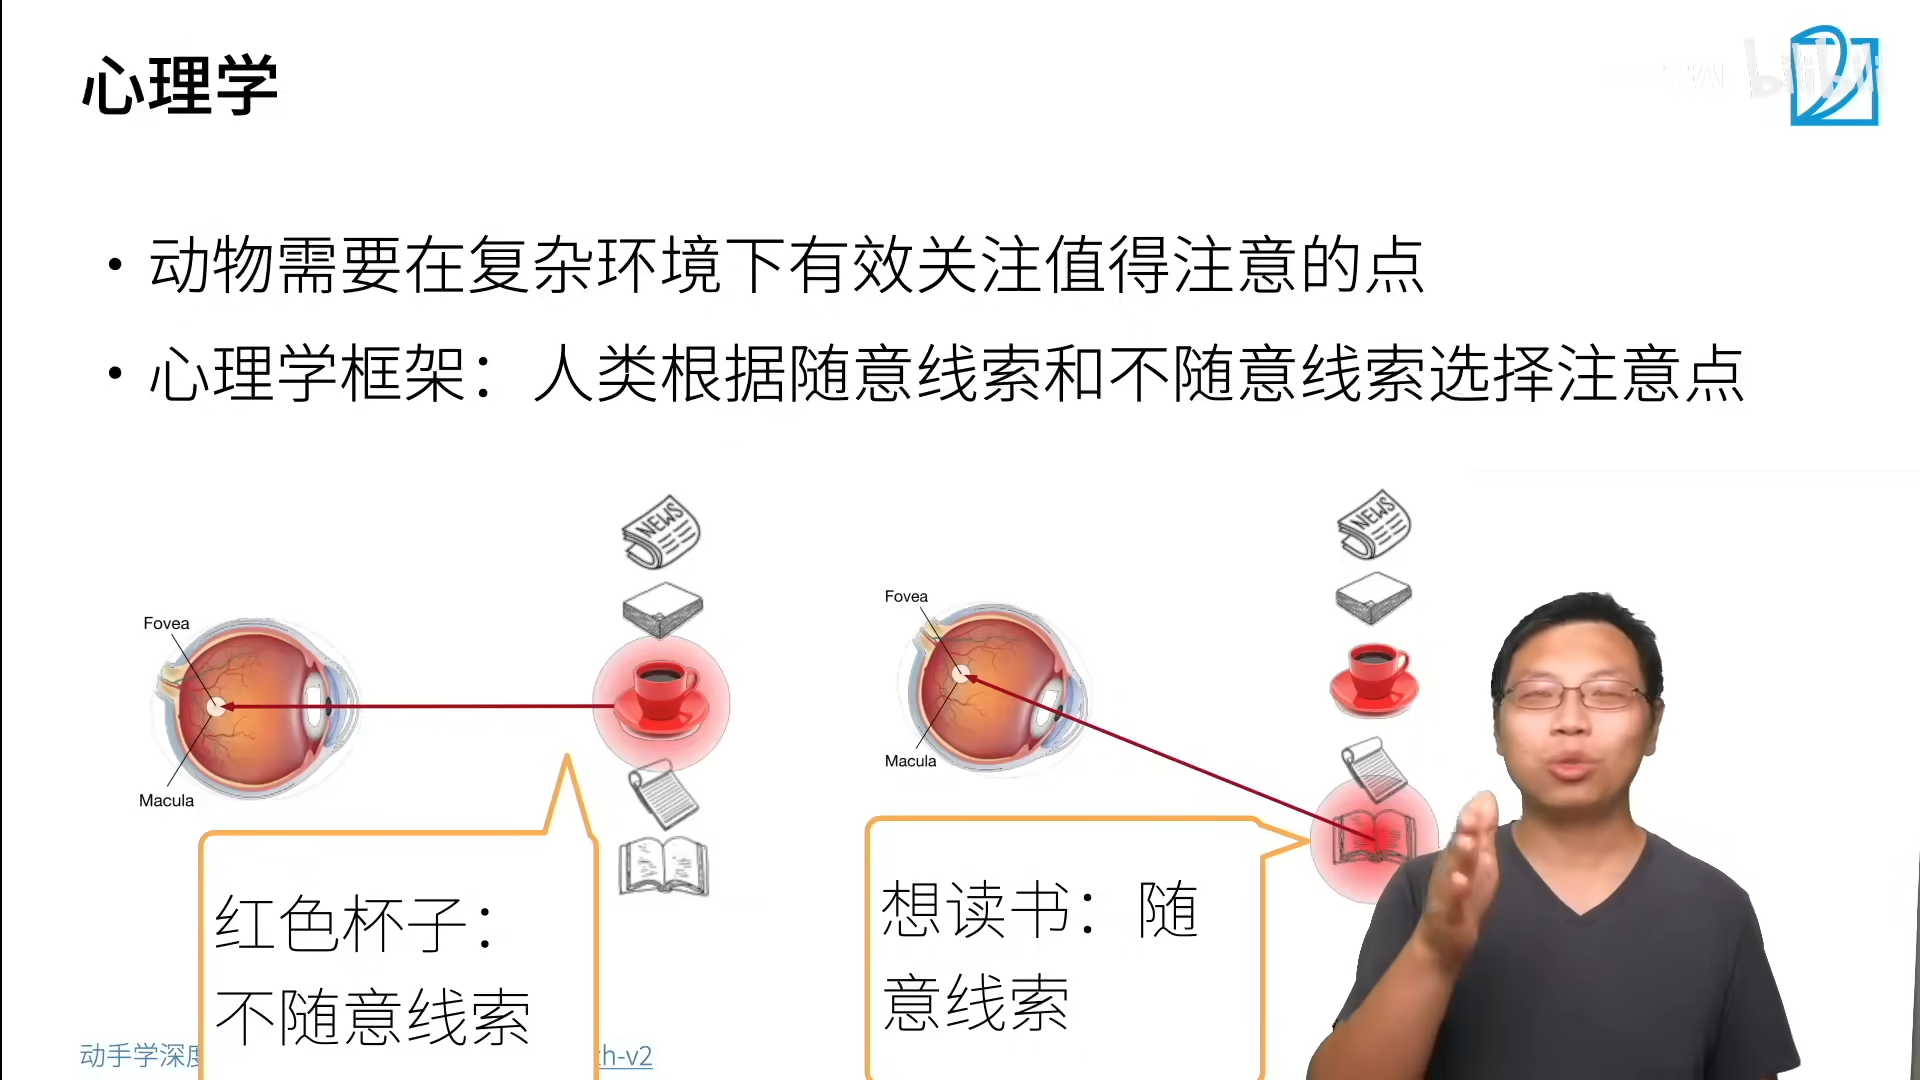

# 注意力机制
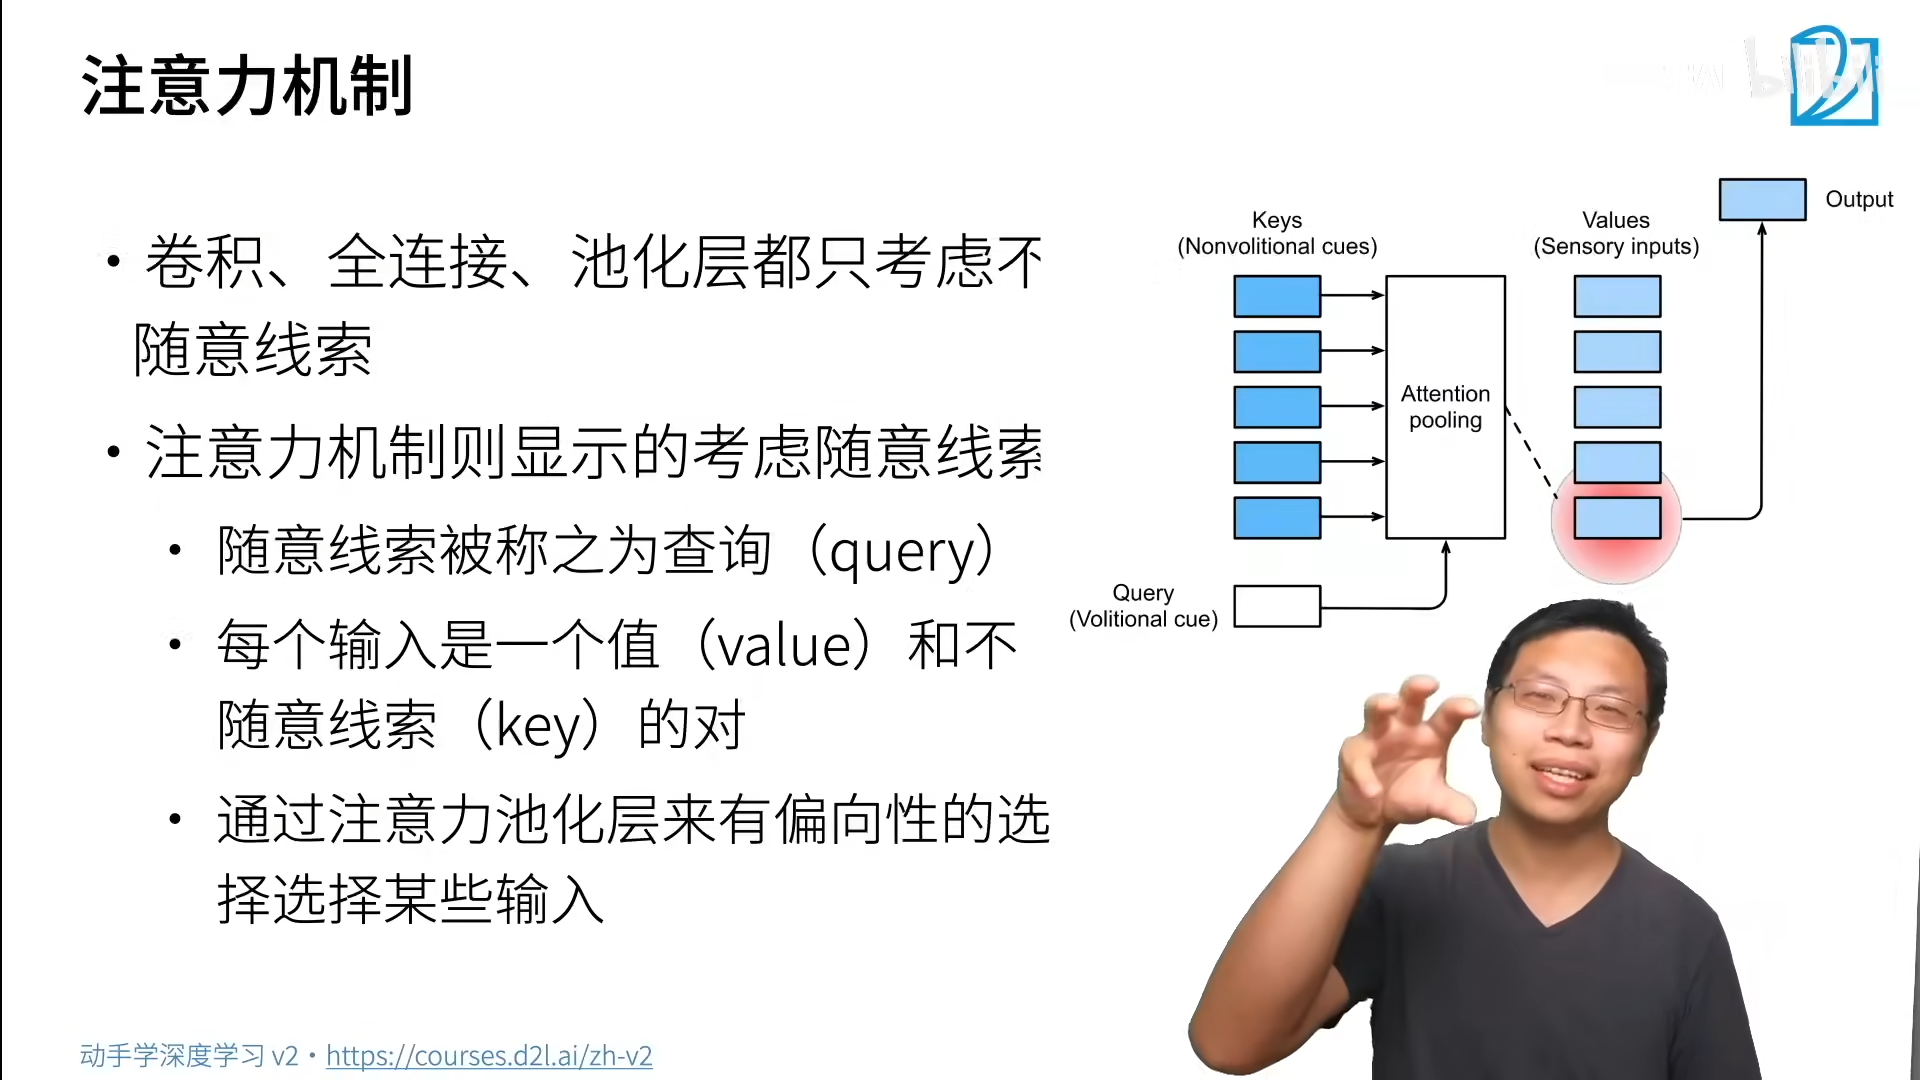

# 非参注意力池化层
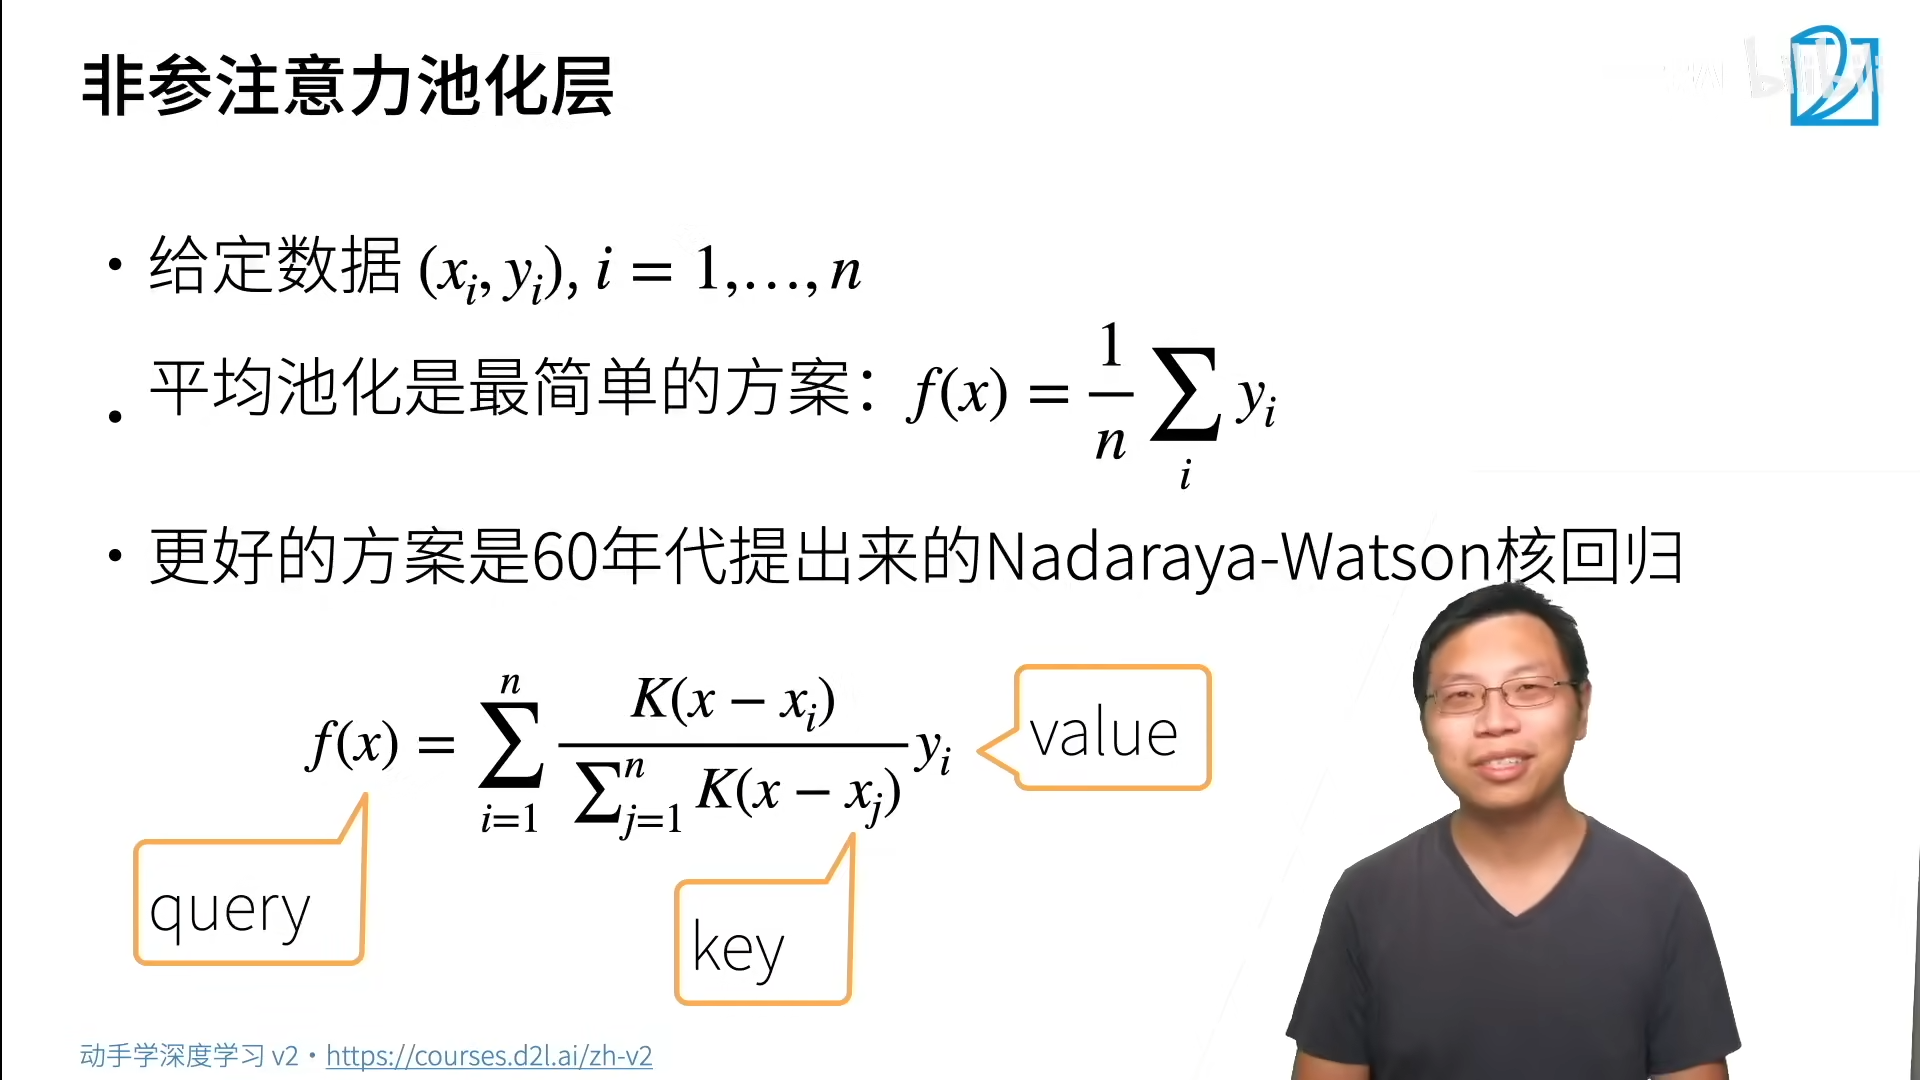

# Nadaraya-Watson核回归
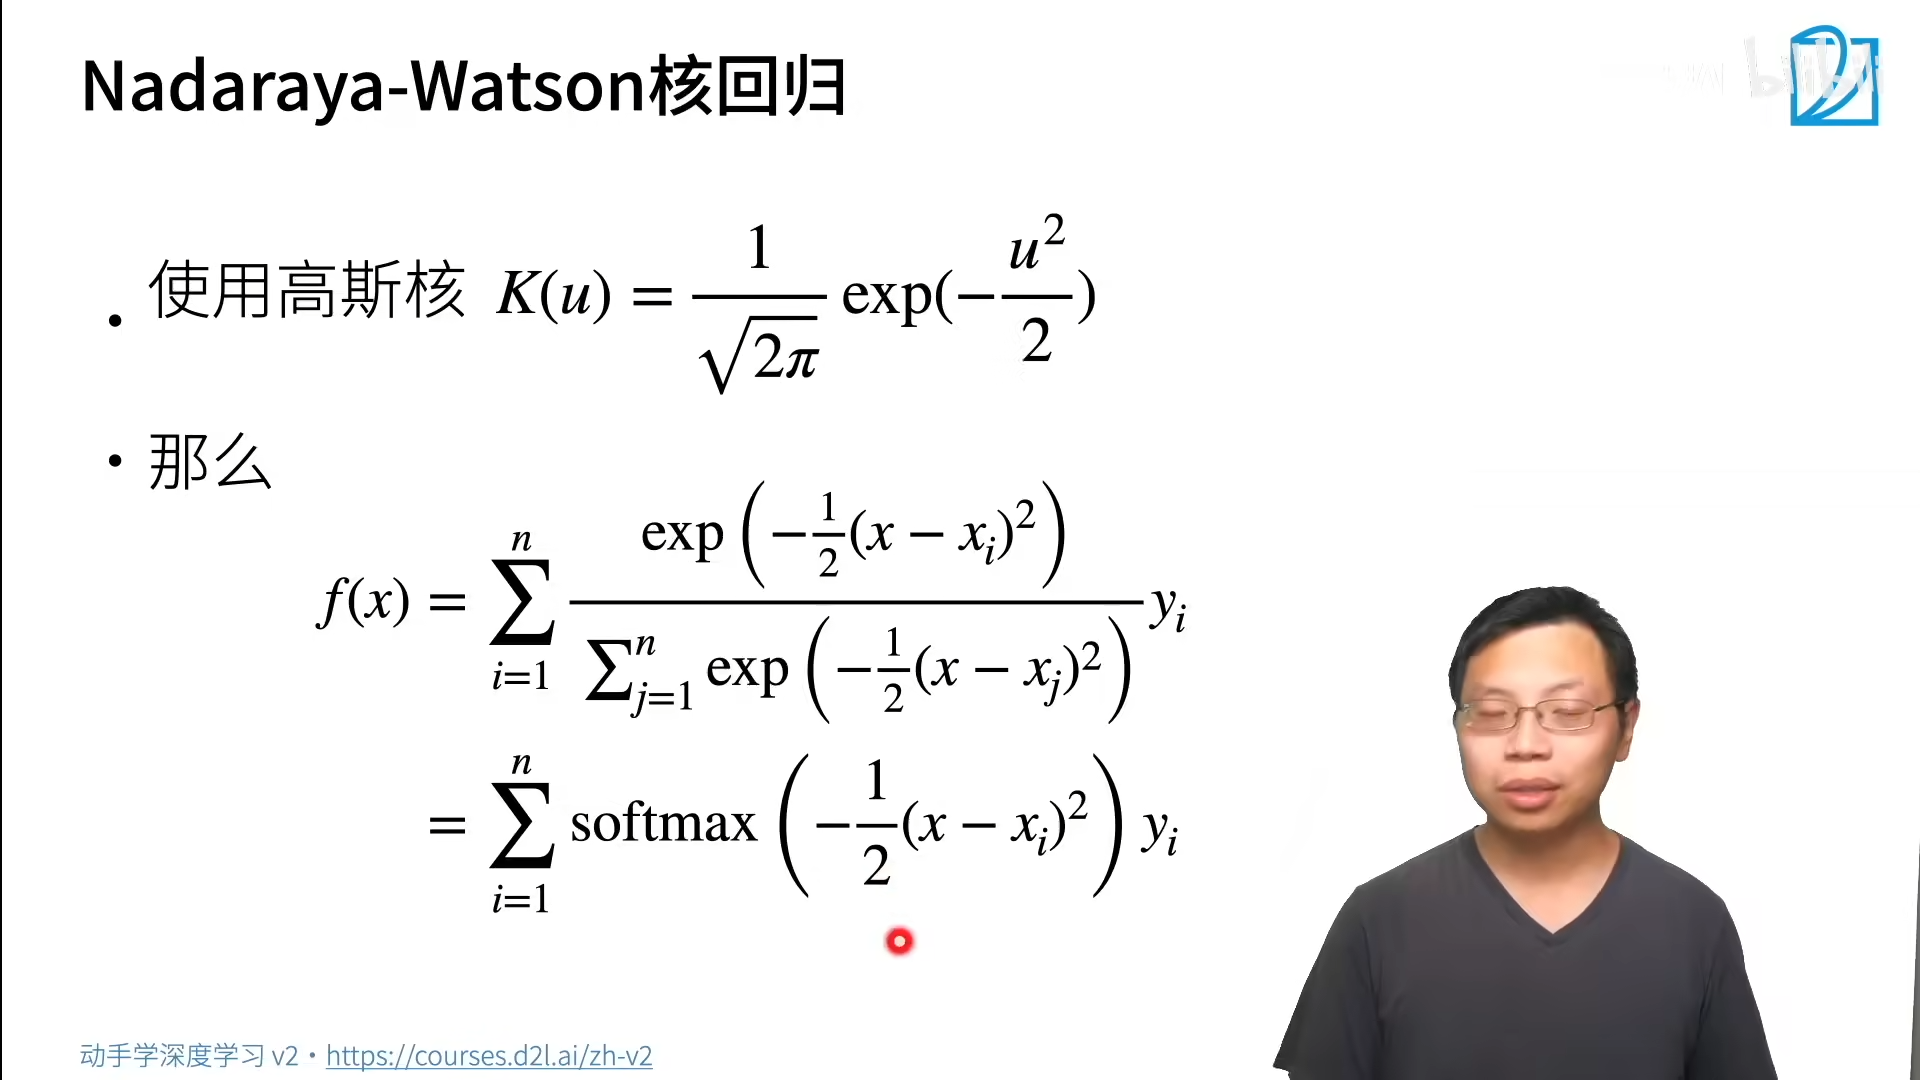

# 参数化的注意力机制
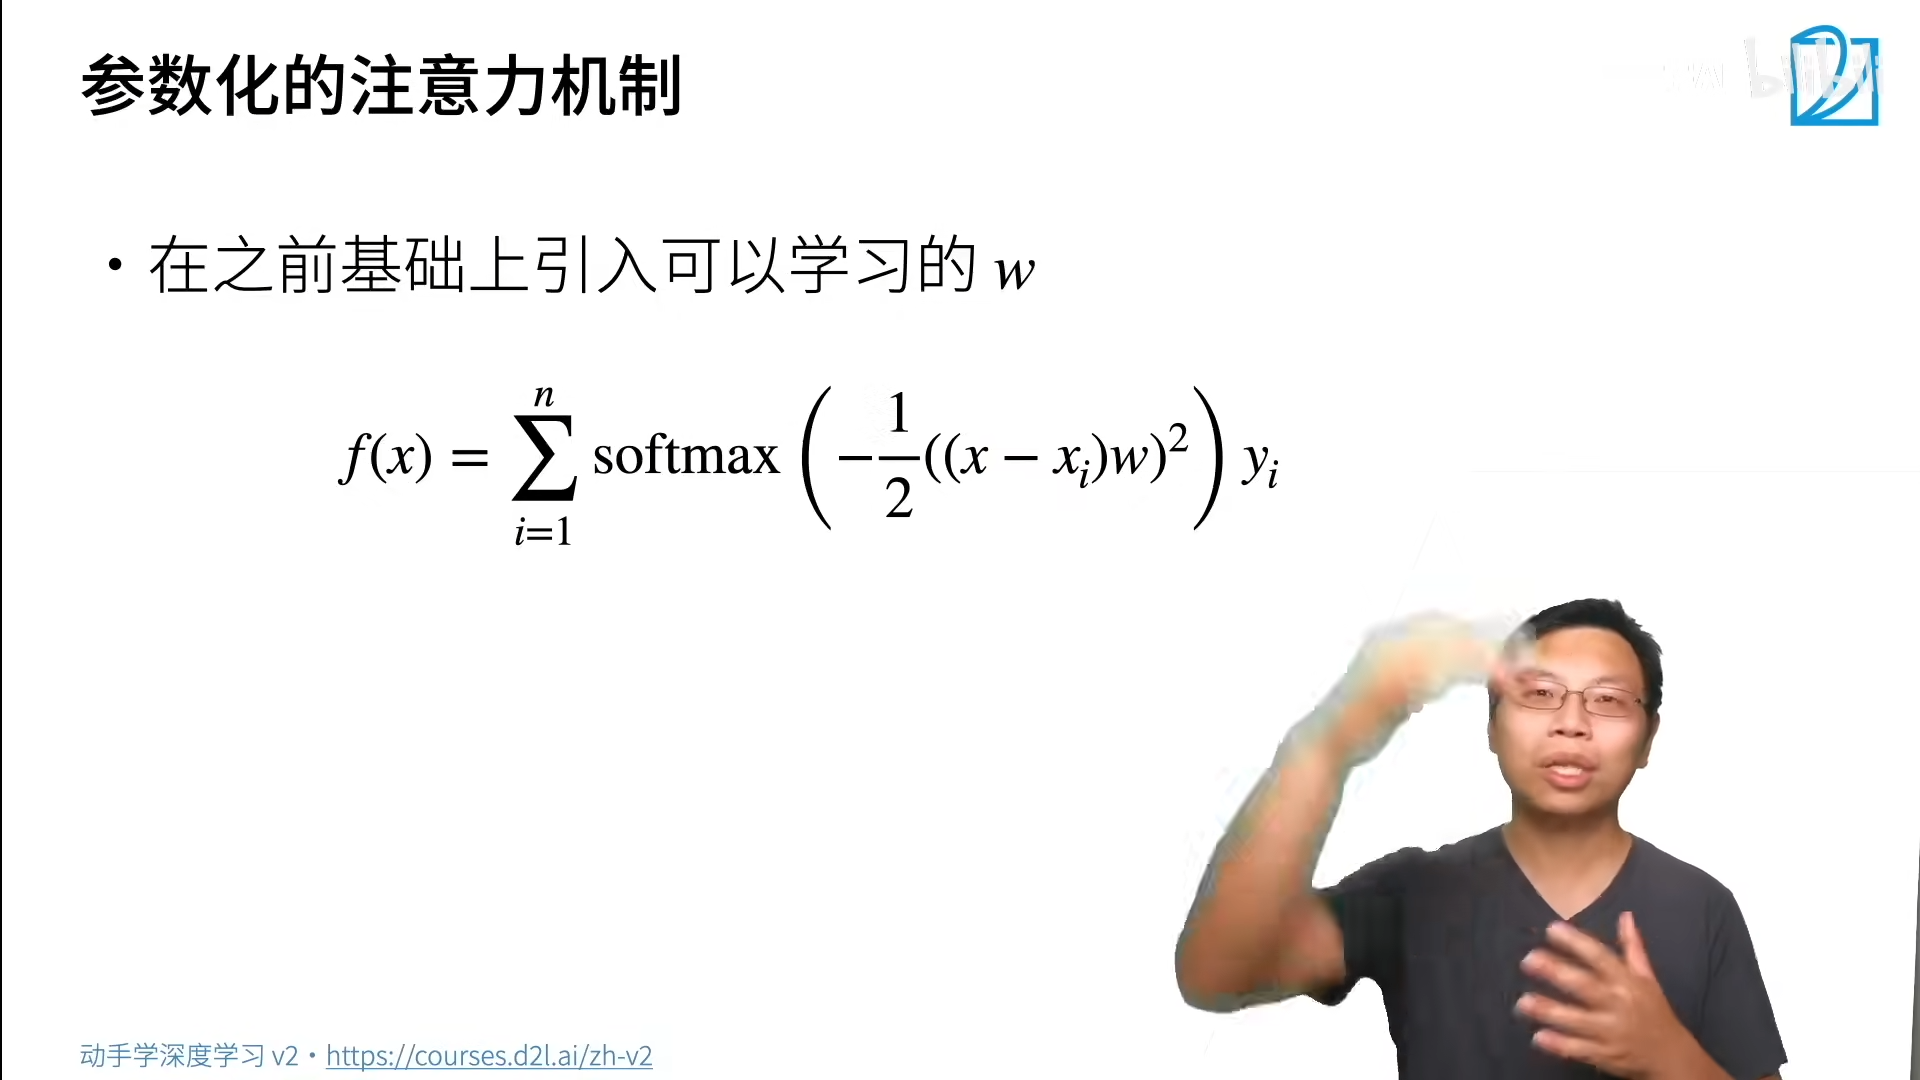

# 总结
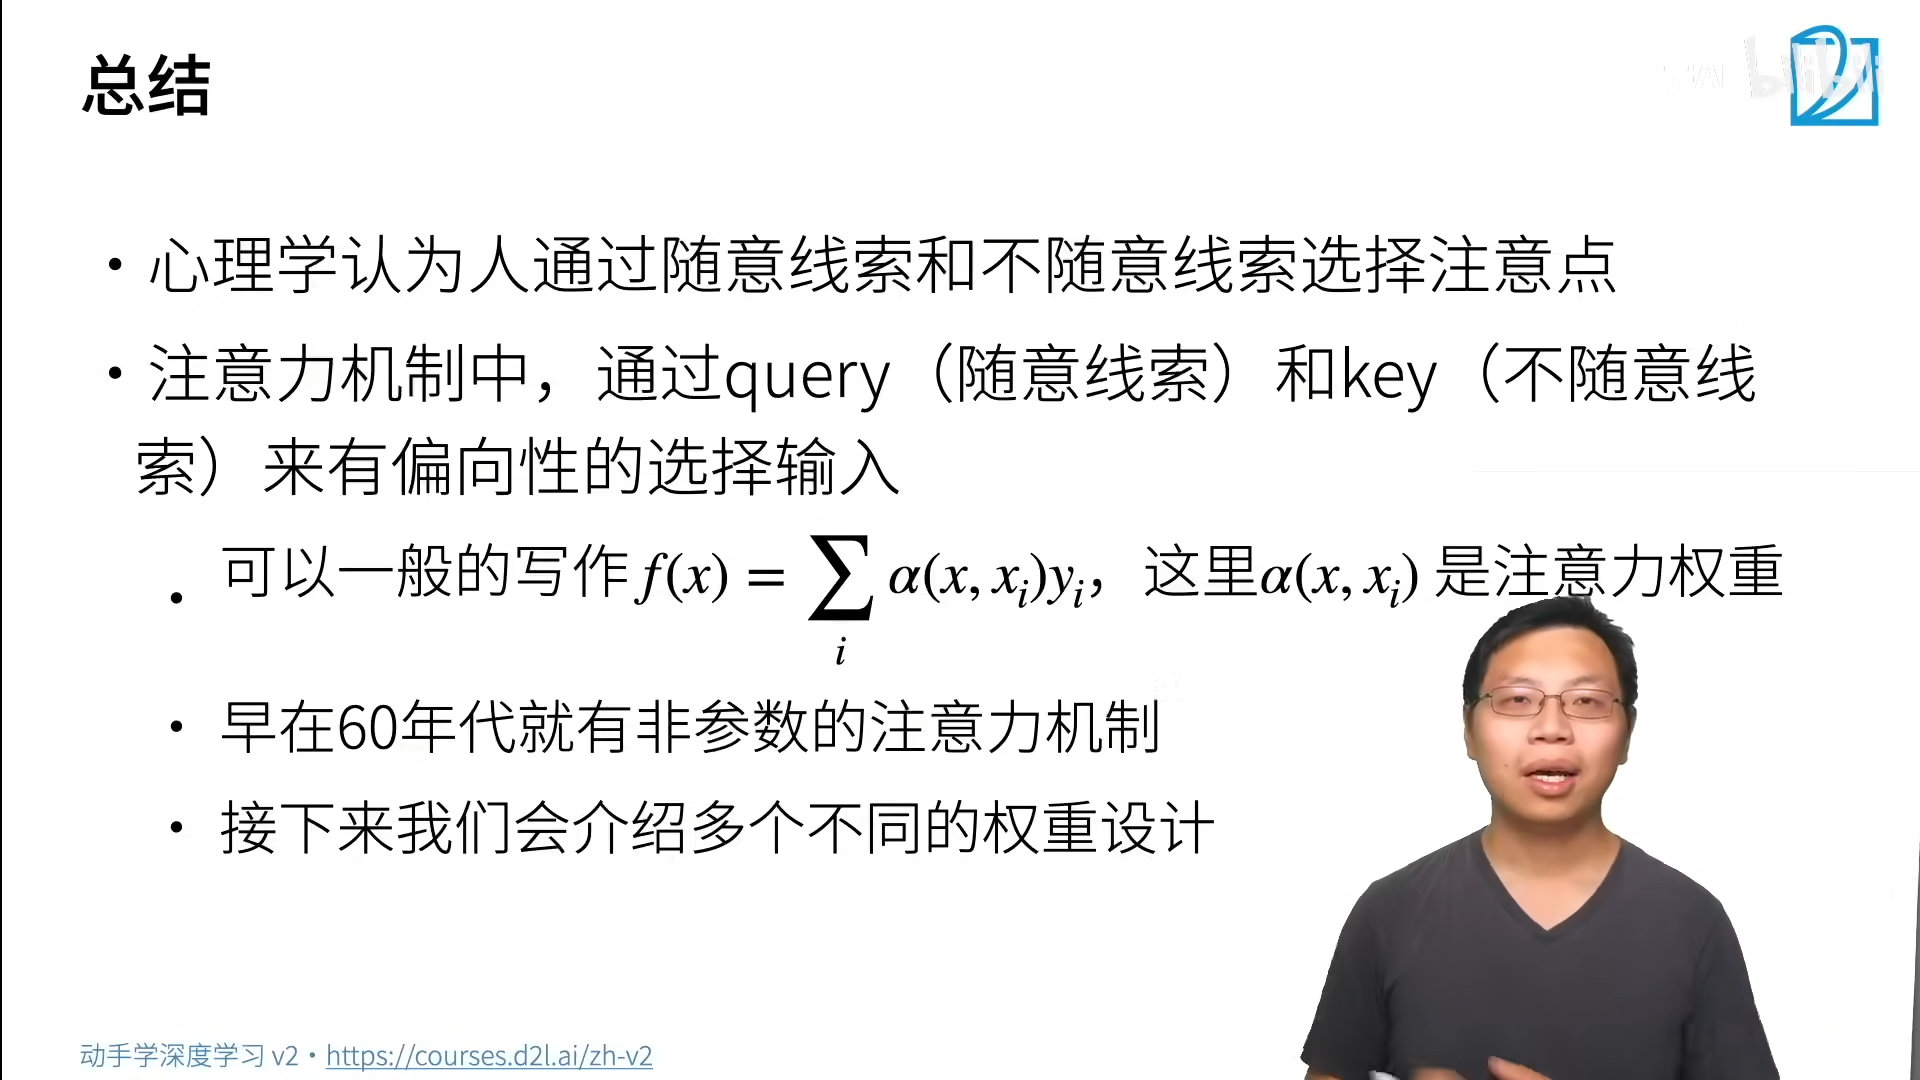

# 1. 注意力机制

In [13]:
import torch
from torch import nn
from d2l import torch as d2l

In [14]:
# 生成数据集
# 训练集样本数量
n_train = 50
# 生成训练集特征x_train，范围为[0, 5)，并进行排序
x_train, _ = torch.sort(torch.rand(n_train) * 5)
print(f"x_train:{x_train}")
# 定义函数f，用于生成标签y
def f(x):
    return 2 * torch.sin(x) + x**0.8
# 生成训练集标签y_train，并加上服从正态分布的噪声
y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))
print(f"y_train:{y_train}")
# 生成测试集特征x_test，范围为[0, 5)，步长为0.1
x_test = torch.arange(0, 5, 0.1)
# 生成测试集的真实标签y_truth
y_truth = f(x_test)
# 计算测试集样本数量
n_test = len(x_test)
n_test

x_train:tensor([0.0627, 0.2215, 0.3512, 0.3765, 0.3839, 0.5157, 0.6435, 0.9921, 1.0332,
        1.0906, 1.1919, 1.3002, 1.4268, 1.4605, 1.5610, 1.5772, 1.7230, 1.7897,
        2.0418, 2.1373, 2.1592, 2.3794, 2.5274, 2.5351, 2.6753, 2.9804, 3.1287,
        3.3807, 3.5730, 3.6612, 3.6815, 3.7359, 3.7865, 3.7906, 3.9584, 4.0664,
        4.2569, 4.3090, 4.3276, 4.4478, 4.5055, 4.5198, 4.5648, 4.8332, 4.8916,
        4.9224, 4.9606, 4.9809, 4.9836, 4.9888])
y_train:tensor([-0.5099,  1.3713,  0.7414,  1.6854,  0.5653,  1.4516,  1.8224,  2.0984,
         1.9853,  2.4953,  3.9187,  3.4138,  2.9488,  3.1639,  2.7900,  3.8004,
         3.2452,  3.3019,  3.2105,  4.3103,  3.5877,  4.6611,  2.8964,  2.7314,
         2.8044,  3.3481,  2.5252,  2.3418,  2.3246,  2.6429,  1.2803,  1.7763,
         2.7139,  1.2942,  1.6879,  1.5129,  1.1125,  1.4072,  0.6136,  1.9500,
         1.7791,  2.0236,  1.5268,  0.9666,  1.6811,  1.6573,  0.5177,  1.3212,
         1.9268,  1.7874])


50

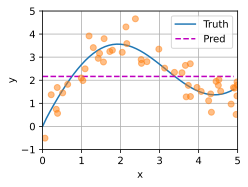

In [15]:
# 绘制核回归结果的图像
def plot_kernel_reg(y_hat):
    # 绘制x_test和对应的真实标签y_truth以及预测标签y_hat的图像
    d2l.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth','Pred'],
            xlim=[0,5], ylim=[-1,5])
    # 绘制训练集的散点图，用圆圈表示
    d2l.plt.plot(x_train, y_train, 'o', alpha=0.5)
# 将y_train的均值重复n_test次作为预测标签y_hat  
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
# 调用plot_kernel_reg函数，绘制核回归结果的图像
plot_kernel_reg(y_hat)

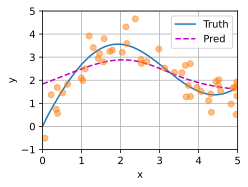

In [16]:
# 非参数注意力汇聚
# 将测试集特征x_test重复n_train次并重新reshape为二维矩阵
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
# 计算注意力权重，通过对特征差值的平方取负并除以2，再进行softmax归一化
attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)  
# 注意力权重与训练集标签y_train进行矩阵乘法得到预测标签y_hat
y_hat = torch.matmul(attention_weights, y_train)
# 调用plot_kernel_reg函数，绘制非参数注意力汇聚的核回归结果图像
plot_kernel_reg(y_hat)

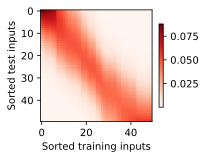

In [17]:
# 注意力权重
# 可视化注意力权重
d2l.show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),
                xlabel='Sorted training inputs', ylabel='Sorted test inputs')   

In [18]:
# 带参数注意力汇聚
# 假定两个张量的形状分别是(n,a,b)和(n,b,c)，它们的批量矩阵乘法输出的形状为(n.a,c)  
# 创建形状为(2,1,4)的张量X，元素全为1
X = torch.ones((2,1,4))
# 创建形状为(2,4,6)的张量Y，元素全为1
Y = torch.ones((2,4,6))
# 执行批量矩阵乘法，并输出结果的形状
torch.bmm(X, Y).shape

torch.Size([2, 1, 6])

In [19]:
# 使用小批量矩阵乘法来计算小批量数据中的加权平均值
# 创建形状为(2,10)的权重张量，每个权重为0.1
weights = torch.ones((2,10)) * 0.1
# 创建形状为(2,10)的值张量，从0到19的连续数值
values = torch.arange(20.0).reshape((2,10))
# 执行小批量矩阵乘法，计算加权平均值
torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1))

tensor([[[ 4.5000]],

        [[14.5000]]])

In [20]:
# 带参数的注意力汇聚
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # 创建形状为(1,)的参数张量w，用于调整注意力权重
        self.w = nn.Parameter(torch.rand((1,),requires_grad=True))  
        
    def forward(self, queries, keys, values):
        # 重复queries并调整形状，使其与keys具有相同的列数
        queries = queries.repeat_interleave(keys.shape[1]).reshape(-1,keys.shape[1])   
        # 计算注意力权重，通过调整参数w对注意力进行调节
        self.attention_weights = nn.functional.softmax(-((queries - keys) * self.w)**2/2,dim=1)     
        # 执行带参数的注意力汇聚，并返回最终结果的形状调整
        return torch.bmm(self.attention_weights.unsqueeze(1),values.unsqueeze(-1)).reshape(-1)   

In [21]:
# 将训练数据集转换为键和值
# 将x_train在行维度上重复n_train次，形成一个矩阵X_tile
X_tile = x_train.repeat((n_train, 1))
# 将y_train在行维度上重复n_train次，形成一个矩阵Y_tile
Y_tile = y_train.repeat((n_train, 1))
# 通过掩码操作，从X_tile中排除对角线元素，得到键矩阵keys
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train,-1))  
# 通过掩码操作，从Y_tile中排除对角线元素，得到值矩阵values
values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape(n_train, -1) 

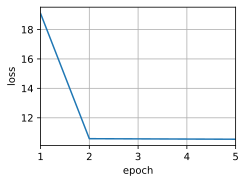

In [22]:
# 训练带参数的注意力汇聚模型
# 创建带参数的注意力汇聚模型
net = NWKernelRegression()
# 创建均方误差损失函数，用于计算损失
loss = nn.MSELoss(reduction='none')
# 创建随机梯度下降优化器，用于参数更新
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
# 创建动画绘制器，用于绘制损失曲线
animator = d2l.Animator(xlabel='epoch',ylabel='loss',xlim=[1,5])

# 遍历5次
for epoch in range(5):
    # 清零梯度
    trainer.zero_grad()
    # 计算损失
    l = loss(net(x_train, keys, values), y_train) / 2
    # 反向传播，计算梯度
    l.sum().backward()
    # 更新参数
    trainer.step()
    # 打印当前的损失
    print(f'epoch {epoch+1}, loss {float(l.sum()):.6f}')
    # 绘制损失曲线
    animator.add(epoch+1, float(l.sum()))

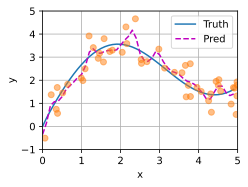

In [23]:
# 预测结果绘制
# 将训练数据集的输入在行维度上重复n_test次，形成键矩阵keys
keys = x_train.repeat((n_test, 1))
# 将训练数据集的输出在行维度上重复n_test次，形成值矩阵values
values = y_train.repeat((n_test, 1))
# 使用训练好的模型进行预测，得到预测结果y_hat
y_hat = net(x_test, keys, values).unsqueeze(1).detach()
# 绘制预测结果
plot_kernel_reg(y_hat)

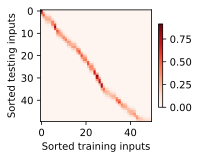

In [24]:
# 曲线在注意力权重较大的区域变得更不平滑
d2l.show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
                 xlabel='Sorted training inputs', ylabel='Sorted testing inputs')   